In [8]:
import json
import os
import numpy as np
import jax
import jax.numpy as jnp
import numpyro
import numpyro.distributions as dist
from numpyro.infer import SVI, Trace_ELBO
from numpyro.infer.autoguide import AutoNormal
from numpyro.optim import Adam
import matplotlib.pyplot as plt
from tqdm.notebook import tqdm

from scipy.special import expit  # sigmoid

In [9]:
# helpers
def binomial(n_samples, theta_like=0.7, seed=20):
    np.random.seed(seed)
    data = np.random.binomial(n_samples, theta_like)
    return data

def load_config(config_file="config.json"):

    with open(config_file, 'r') as f:
        config = json.load(f)
    return config

def _logistic_normal_mean_std_mc(mu, sigma, n_samples=10_000, seed=0):
    mu = float(np.squeeze(mu))
    sigma = float(np.squeeze(sigma))
    rng = np.random.default_rng(seed)
    z = rng.normal(loc=mu, scale=sigma, size=n_samples)
    theta = expit(z)
    return float(theta.mean()), float(theta.std(ddof=1))

def _trace_locscale_to_theta_moments(loc_trace, scale_trace, n_samples=10_000, seed=0):
    """Batched transformation using JAX for maximum speed."""
    # originally looped element-by-element then we tried vector-broadcasting
    loc_trace = jnp.asarray(loc_trace, dtype=jnp.float32)
    scale_trace = jnp.asarray(scale_trace, dtype=jnp.float32)
    
    T = loc_trace.shape[0]
    batch_size = 5000  # Process 5000 timepoints at once (50M elements = ~200MB)
    
    out_mean = []
    out_std = []
    
    key = jax.random.PRNGKey(seed)
    
    for start_idx in range(0, T, batch_size):
        end_idx = min(start_idx + batch_size, T)
        batch_loc = loc_trace[start_idx:end_idx]
        batch_scale = scale_trace[start_idx:end_idx]
        
        # Use JAX's random generation - much faster
        key, subkey = jax.random.split(key)
        z = jax.random.normal(subkey, shape=(batch_loc.shape[0], n_samples)) * batch_scale[:, None] + batch_loc[:, None]
        theta = jax.nn.sigmoid(z)  # JAX's optimized sigmoid
        
        out_mean.append(jnp.mean(theta, axis=1))
        out_std.append(jnp.std(theta, axis=1, ddof=1))
    
    return np.concatenate(out_mean), np.concatenate(out_std)

data_gen = binomial


In [10]:
config_file = "../beta_config.json"
config = load_config(config_file)

theta_like = config['theta_like']
alpha_prior = config['alpha_prior']
beta_prior = config['beta_prior']
n_samples = config['n_samples']
max_iters = 50_000
adam_step = 5e-4 # the "default"

data = data_gen(n_samples) if n_samples > 0 else 0
# print parameters
print("prior: Beta({}, {})".format(alpha_prior, beta_prior))
print("Likelihood: Binomial({})".format(theta_like))
print(data)
# true_post = beta_posterior(data, n_samples, alpha_prior, beta_prior)
# print("True posterior: Beta({}, {:.2f})".format(true_post['alpha_post'], true_post['beta_post']) + " with mean {:.2f} and std {:.2f}".format(true_post['mean_post'], true_post['std_post']))
# Note that our plots do compare to the "best variational approximation"

prior: Beta(0.5, 0.6)
Likelihood: Binomial(0.7)
7


In [ ]:
# copy-pasted from beta_numpyro.ipynb
# run in numpyro

def run_restart(seed): 
    def model(y):
        theta = numpyro.sample("theta", dist.Beta(alpha_prior, beta_prior))
        numpyro.sample("obs", dist.Binomial(n_samples, theta), obs=y)
    y_data = jnp.array(data)
    optimizer = Adam(step_size=adam_step, eps=1e-8)

    single_mc_elbo = Trace_ELBO()
    multi_mc_elbo = Trace_ELBO(num_particles=100)

    single_mc_guide = AutoNormal(model)
    multi_mc_guide = AutoNormal(model)

    single_mc_svi = SVI(model, single_mc_guide, optimizer, loss=single_mc_elbo)
    multi_mc_svi = SVI(model, multi_mc_guide, optimizer, loss=multi_mc_elbo)

    def run_svi(rng_key, y_data, svi_model):
        @jax.jit
        def run_single_svi_loop(rng_key, y_data):
            svi_state = svi_model.init(rng_key, y_data)
            def body_fn(i, val):
                svi_state, tracker = val
                svi_state, loss = svi_model.update(svi_state, y_data)
                params = svi_model.get_params(svi_state)
                tracker = {
                    'mu_loc': tracker['mu_loc'].at[i].set(params['theta_auto_loc']),
                    'std_loc': tracker['std_loc'].at[i].set(params['theta_auto_scale'])
                }
                return svi_state, tracker
            tracker = {
                'mu_loc': jnp.zeros(max_iters),
                'std_loc': jnp.zeros(max_iters)
            }
            final_state, final_tracker = jax.lax.fori_loop(0, max_iters, body_fn, (svi_state, tracker))
            final_elbo = svi_model.evaluate(final_state, y_data)
            return final_elbo, final_tracker
        return run_single_svi_loop(rng_key, y_data)

    single_elbo, single_tracker = run_svi(jax.random.PRNGKey(seed), y_data, single_mc_svi)
    multi_elbo, multi_tracker = run_svi(jax.random.PRNGKey(seed + 1000), y_data, multi_mc_svi)
    return single_elbo, single_tracker, multi_elbo, multi_tracker

In [13]:
results = []
for seed in tqdm(range(20)):
    result = run_restart(seed)
    results.append(result)


  0%|          | 0/20 [00:00<?, ?it/s]

  0%|          | 0/20 [00:00<?, ?it/s]

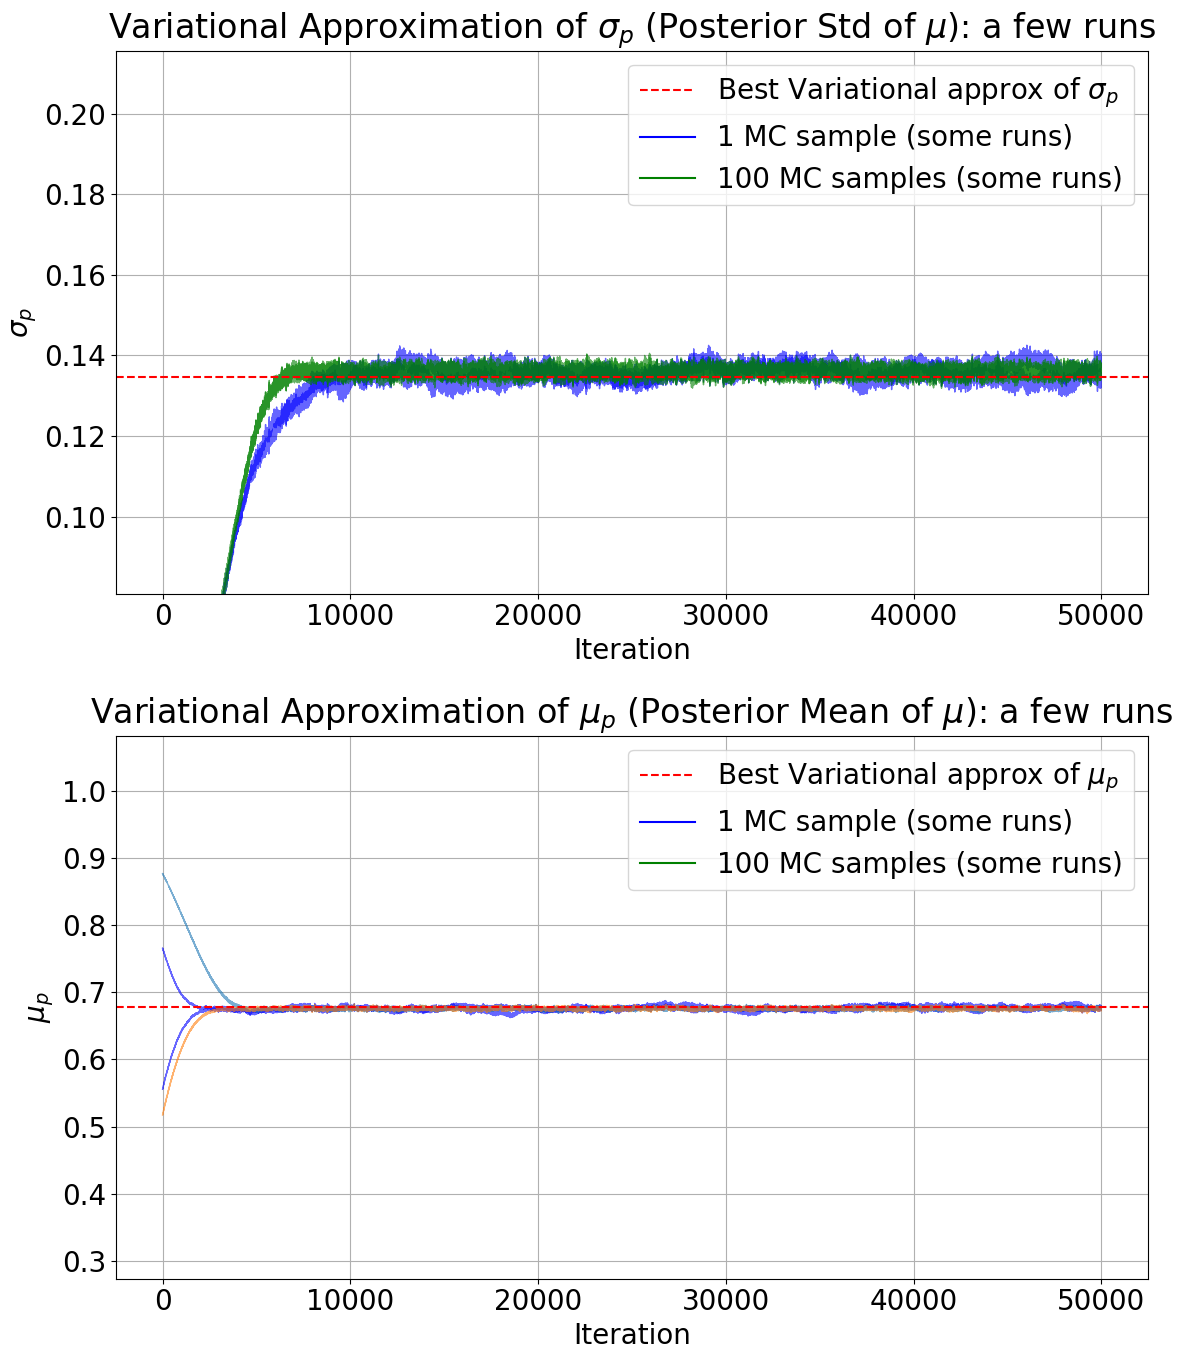

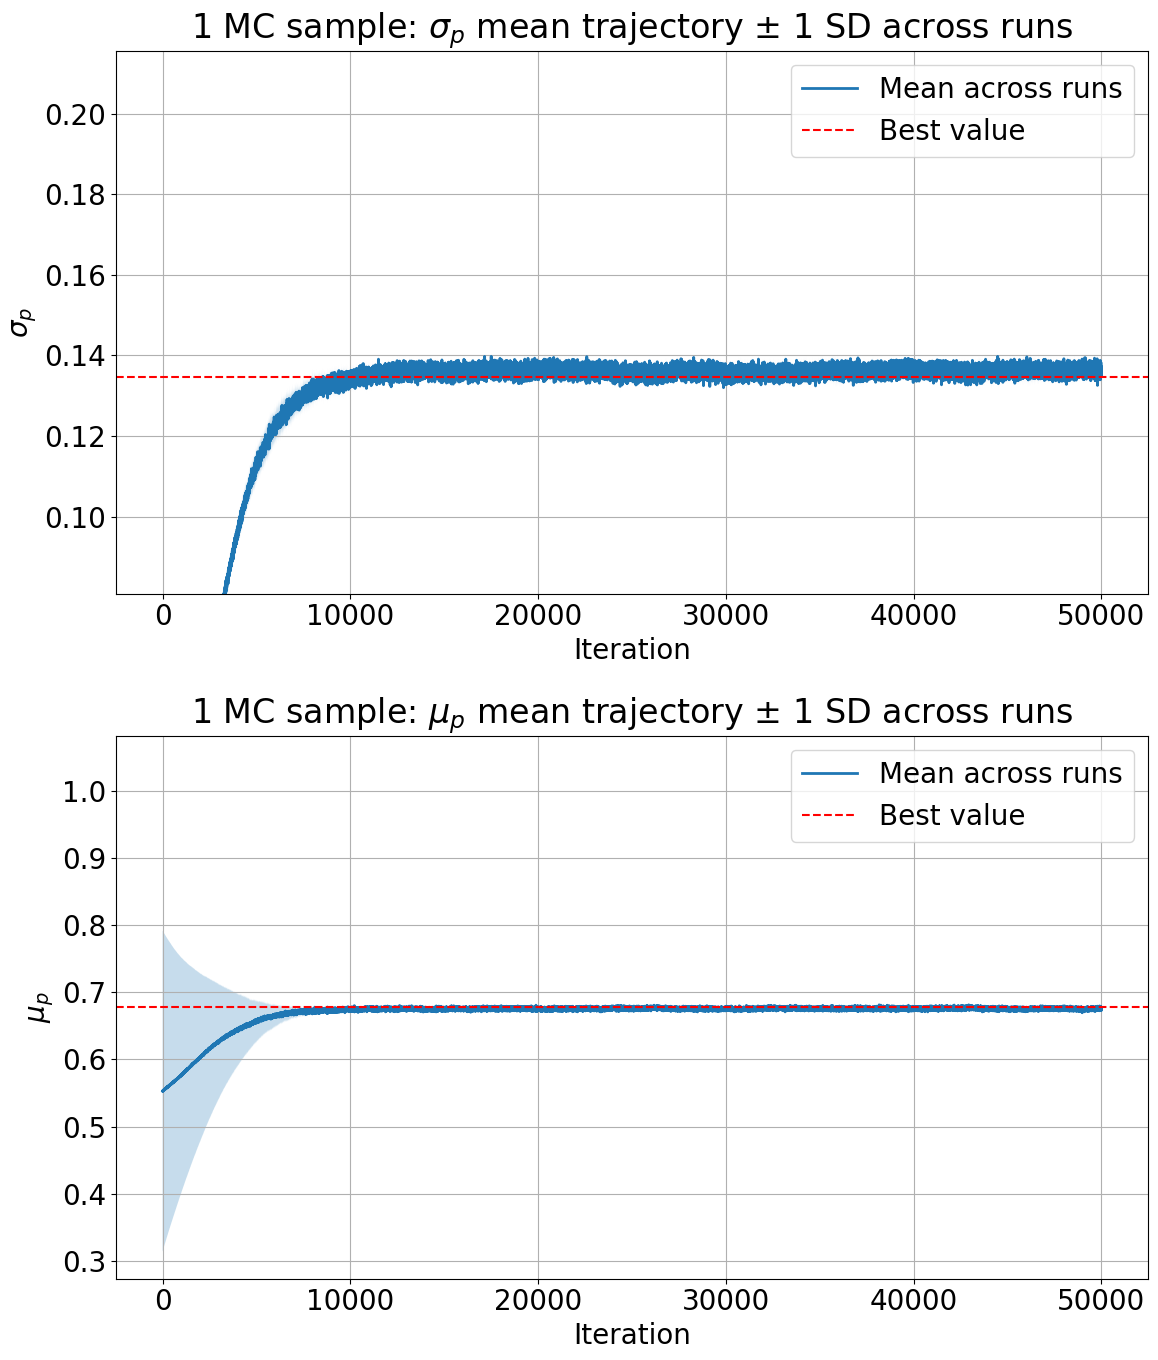

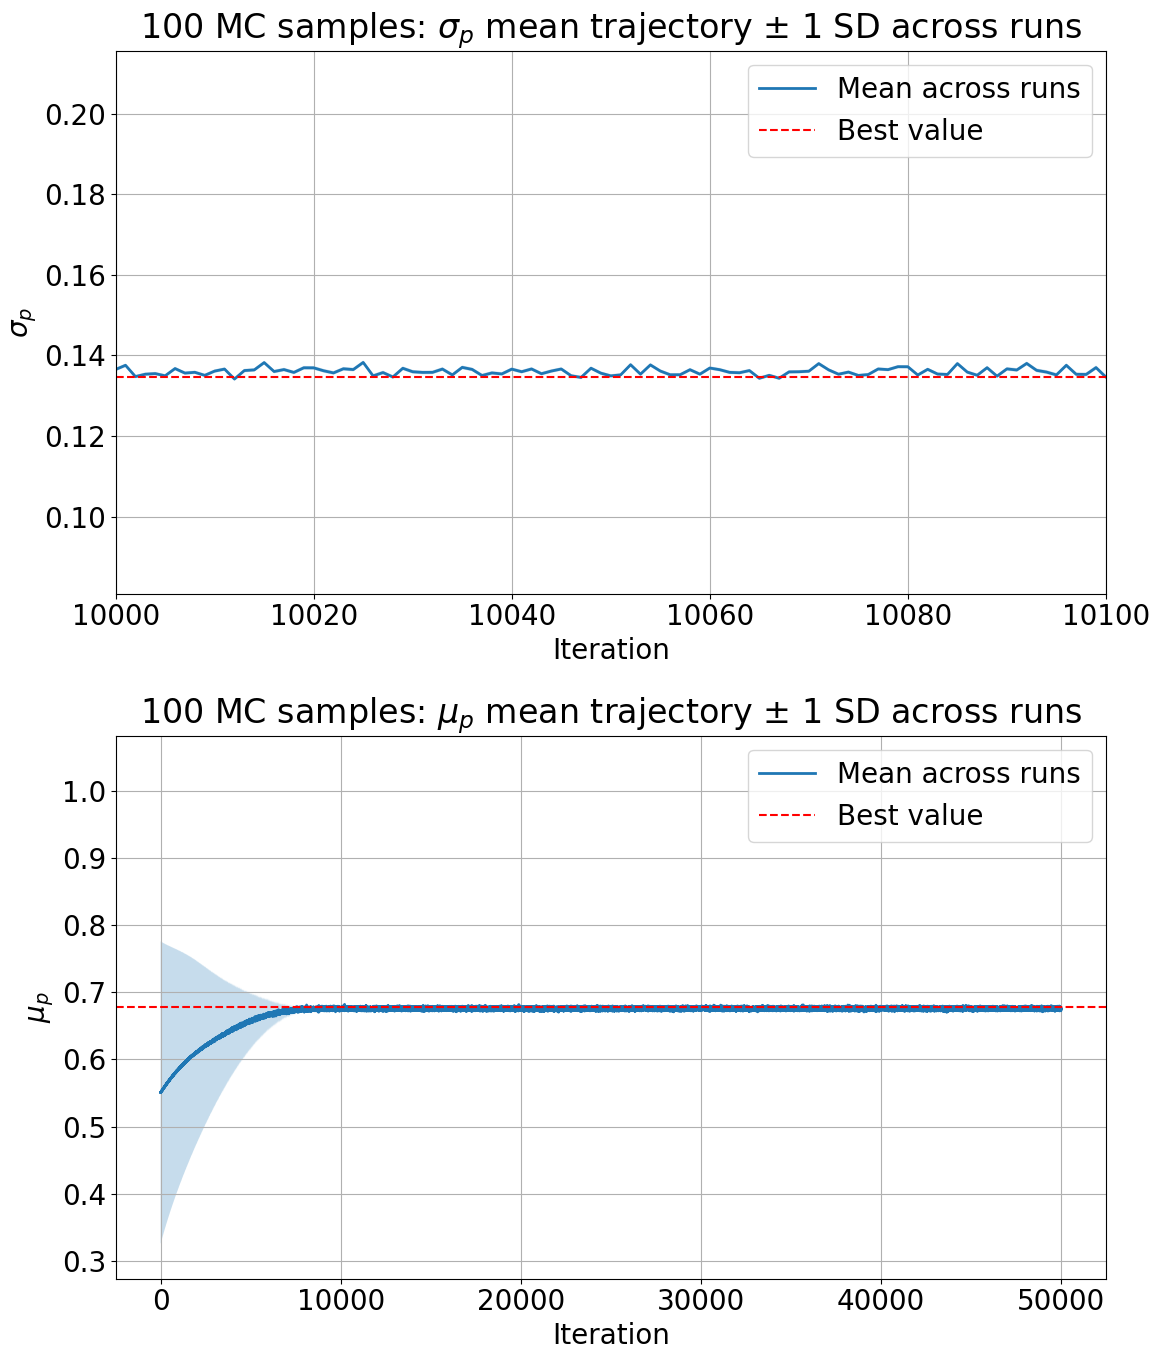

In [ ]:
plt.rcParams.update({'font.size': 20})
# ----------------------------
# unpack results -> stacks also transform
# ----------------------------
single_means, single_stds = [], []
multi_means,  multi_stds  = [], []
for single_elbo, single_tracker, multi_elbo, multi_tracker in tqdm(results):
    # Use vectorized transformation for speed
    single_mu, single_sigma = _trace_locscale_to_theta_moments(
        single_tracker['mu_loc'], single_tracker['std_loc'], n_samples=10_000, seed=0
    )
    multi_mu, multi_sigma = _trace_locscale_to_theta_moments(
        multi_tracker['mu_loc'], multi_tracker['std_loc'], n_samples=10_000, seed=0
    )
    
    single_means.append(single_mu)
    single_stds.append(single_sigma)
    multi_means.append(multi_mu)
    multi_stds.append(multi_sigma)

single_means = np.stack(single_means, axis=0)  # (N, T)
single_stds  = np.stack(single_stds,  axis=0)  # (N, T)
multi_means  = np.stack(multi_means,  axis=0)  # (N, T)
multi_stds   = np.stack(multi_stds,   axis=0)  # (N, T)

N, T = single_means.shape
x = np.arange(T)

# If you have "best" from config, these should be on theta-scale (0,1)
best_mu = float(config["best_mean"]) if "config" in globals() and "best_mean" in config else None
best_std = float(config["best_std"]) if "config" in globals() and "best_std" in config else None
best_mu, best_std = _logistic_normal_mean_std_mc(best_mu, best_std, n_samples=50_000, seed=1)


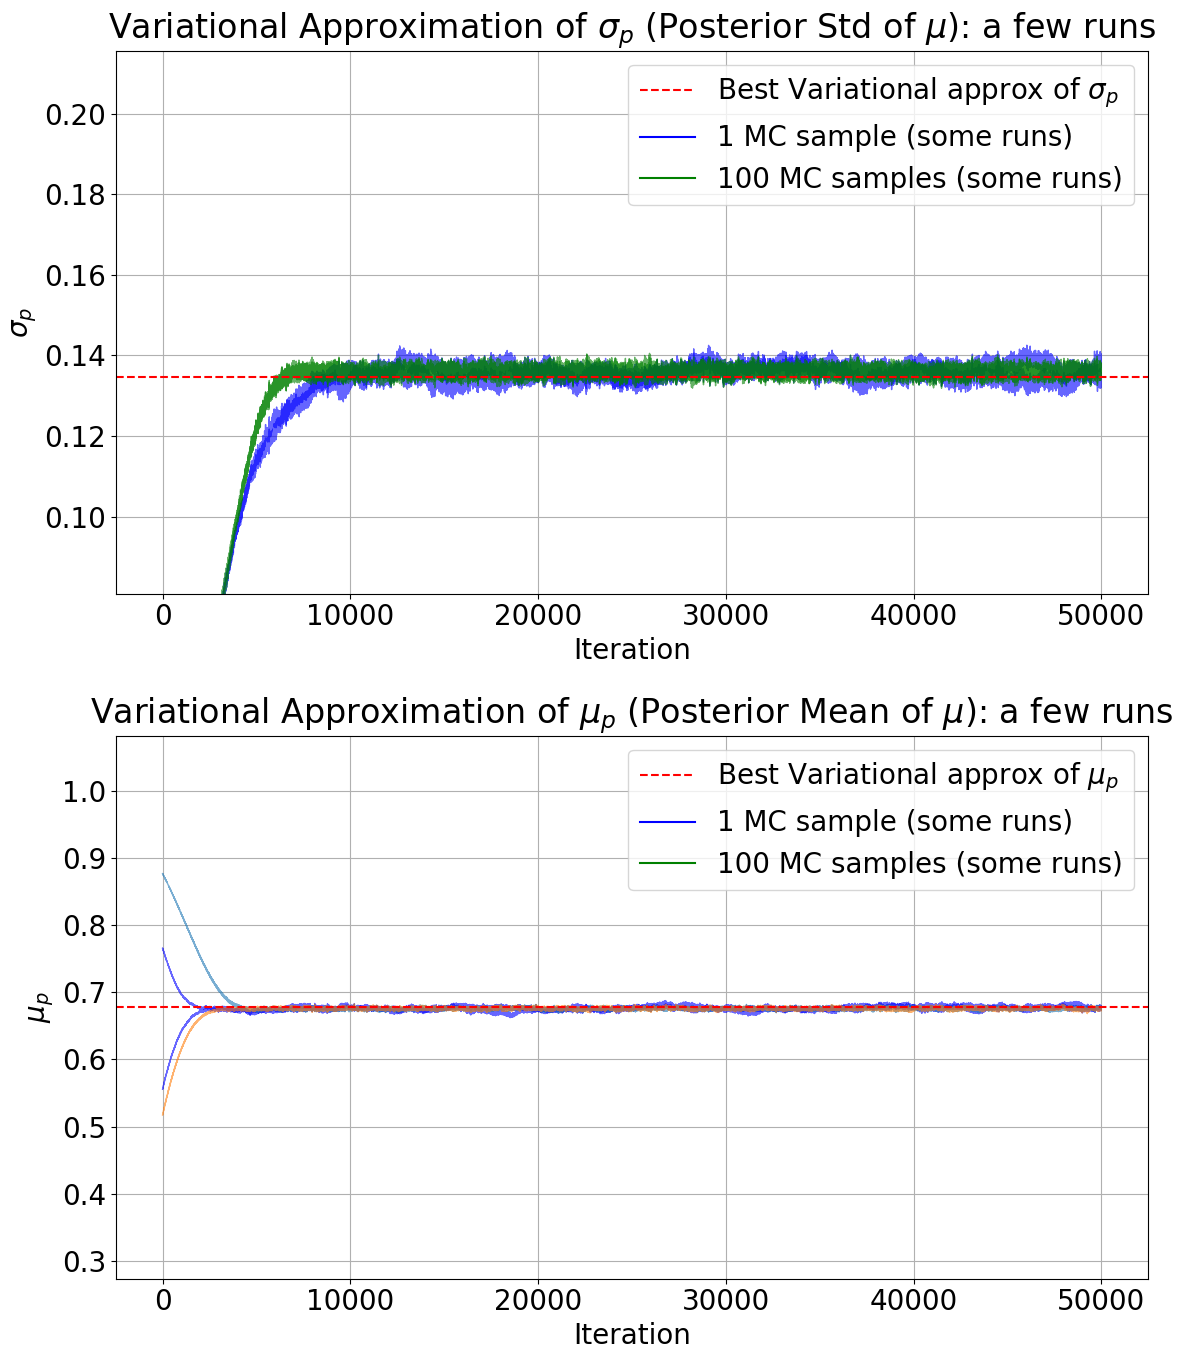

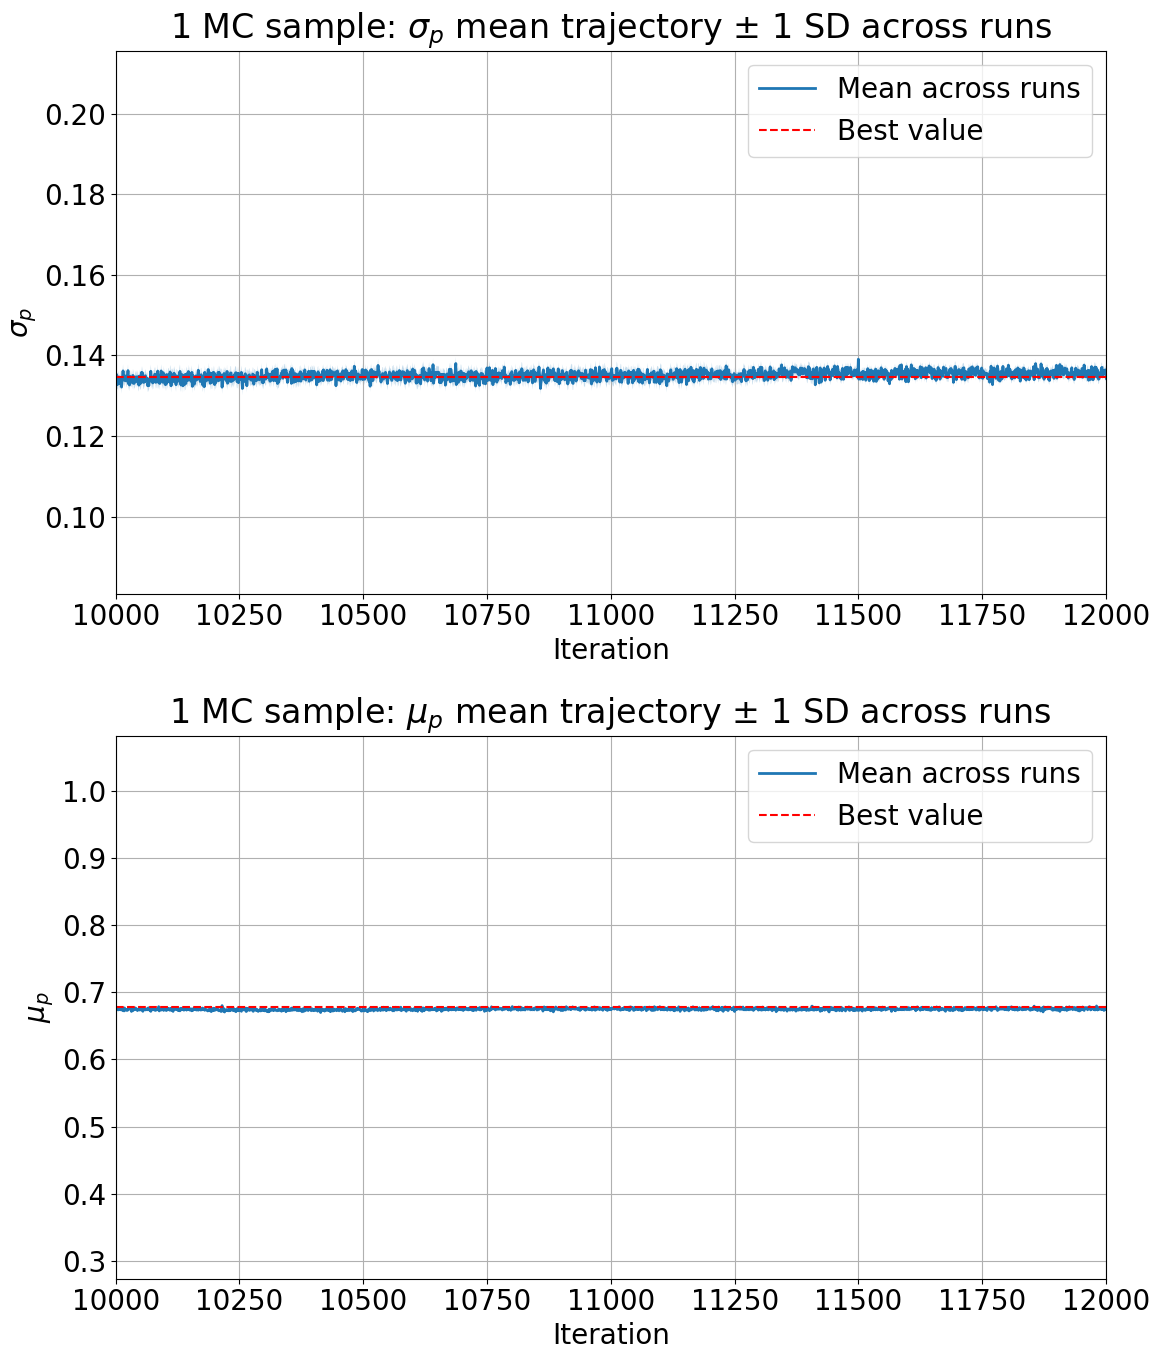

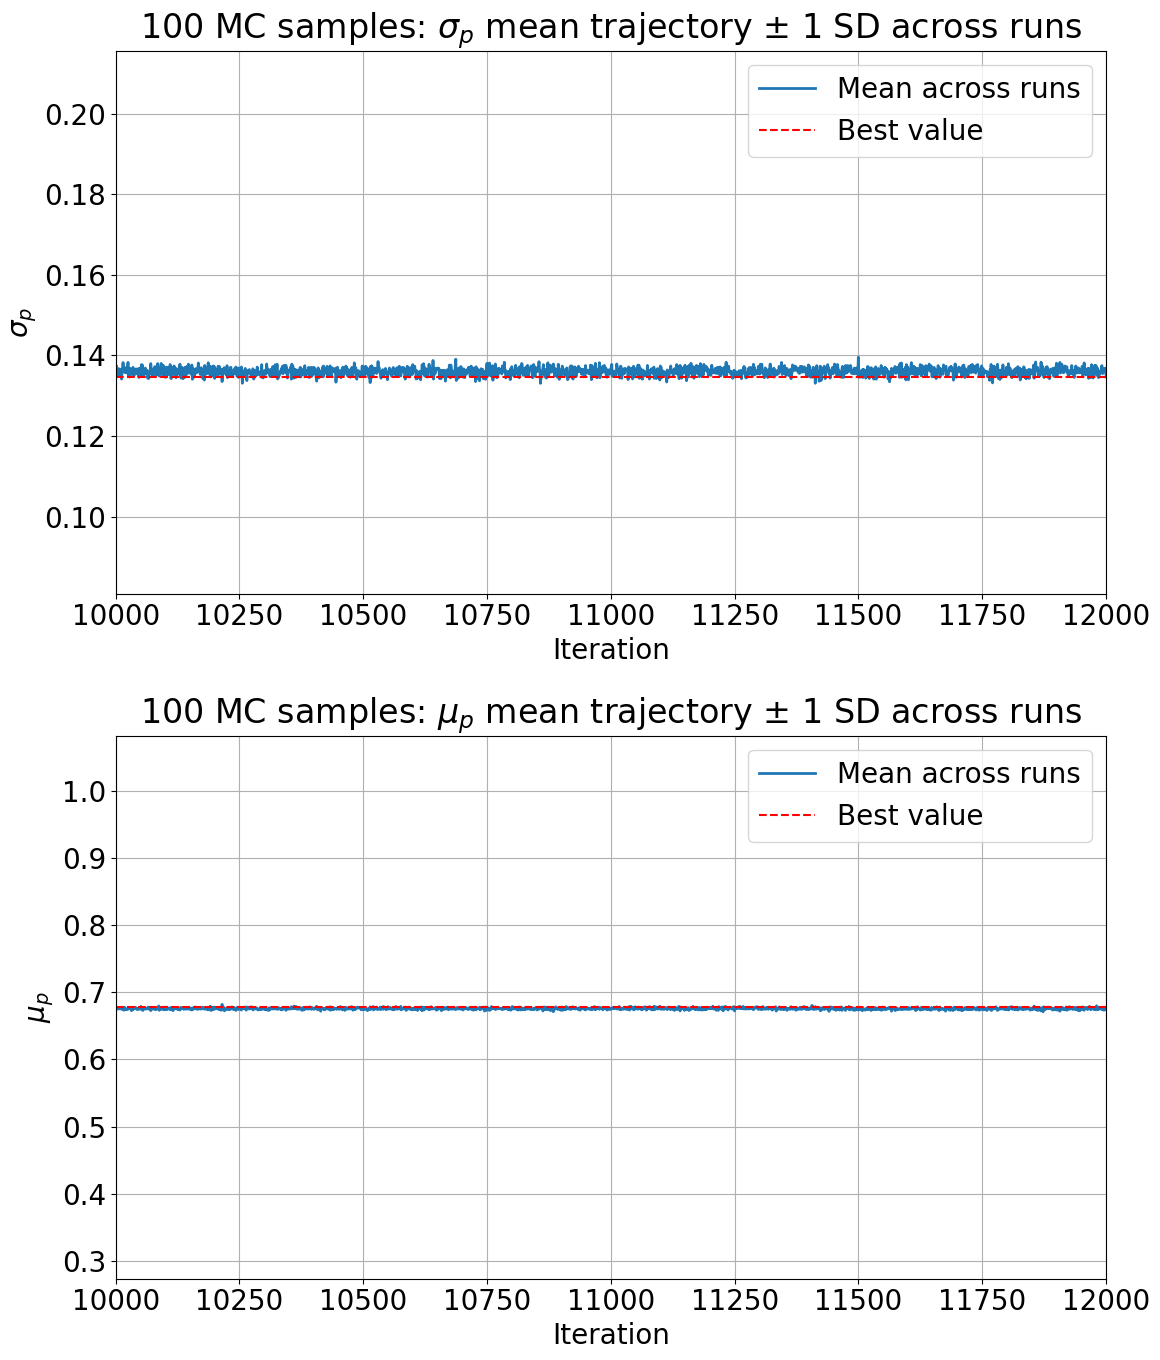

In [26]:

# ----------------------------
# Plot 1: overlay a few trajectories from each condition
# ----------------------------
k = 2  # how many trajectories to show from each
idx = np.linspace(0, N - 1, k, dtype=int)  # deterministic selection

fig, axs = plt.subplots(2, 1, figsize=(12, 14))

# std of mu
for i in idx:
    axs[0].plot(x, single_stds[i], alpha=0.6, linewidth=1, color='blue')
for i in idx:
    axs[0].plot(x, multi_stds[i],  alpha=0.6, linewidth=1, color='green')

axs[0].axhline(best_std, color='red', linestyle='--', label=r'Best Variational approx of $\sigma_p$')
axs[0].set_title(r'Variational Approximation of $\sigma_p$ (Posterior Std of $\mu$): a few runs')
axs[0].set_xlabel('Iteration')
axs[0].set_ylabel(r'$\sigma_p$')
axs[0].grid()
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

# mean of mu
for i in idx:
    axs[1].plot(x, single_means[i], alpha=0.6, linewidth=1, color='blue', label=None)
for i in idx:
    axs[1].plot(x, multi_means[i],  alpha=0.6, linewidth=1, label=None)

axs[1].axhline(best_mu, color='red', linestyle='--', label=r'Best Variational approx of $\mu_p$')
axs[1].set_title(r'Variational Approximation of $\mu_p$ (Posterior Mean of $\mu$): a few runs')
axs[1].set_xlabel('Iteration')
axs[1].set_ylabel(r'$\mu_p$')
axs[1].grid()
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)

# manual legend (so we don’t get 16 duplicate entries)
axs[0].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[0].plot([], [], color='green', label='100 MC samples (some runs)')
axs[0].legend()

axs[1].plot([], [], color='blue', label='1 MC sample (some runs)')
axs[1].plot([], [], color='green', label='100 MC samples (some runs)')
axs[1].legend()

plt.tight_layout()
plt.show()

# ----------------------------
# Plot 2: mean trajectory ± 1 std band across runs (separate plots for 1-MC and 100-MC)
# ----------------------------
def plot_mean_band(ax, x, Y, true_value, title, ylabel):
    """
    Y: (N, T) trajectories
    """
    m = Y.mean(axis=0)
    s = Y.std(axis=0)
    ax.plot(x, m, linewidth=2, label='Mean across runs')
    ax.fill_between(x, m - s, m + s, alpha=0.25)
    ax.axhline(true_value, color='red', linestyle='--', label='Best value')
    ax.set_title(title)
    ax.set_xlabel('Iteration')
    ax.set_ylabel(ylabel)
    ax.grid()
    ax.legend()

# 1 MC sample: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, single_stds, best_std,
    r'1 MC sample: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, single_means, best_mu,
    r'1 MC sample: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)
axs[0].set_xlim(10000, 12000)
axs[1].set_xlim(10000, 12000)
plt.tight_layout()
plt.show()

# 100 MC samples: mean ± sd across runs
fig, axs = plt.subplots(2, 1, figsize=(12, 14))
plot_mean_band(
    axs[0], x, multi_stds, best_std,
    r'100 MC samples: $\sigma_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\sigma_p$'
)
axs[0].set_ylim(best_std * 0.6, best_std * 1.6)

plot_mean_band(
    axs[1], x, multi_means, best_mu,
    r'100 MC samples: $\mu_p$ mean trajectory $\pm$ 1 SD across runs',
    r'$\mu_p$'
)
axs[1].set_ylim(best_mu - 3 * best_std, best_mu + 3 * best_std)
axs[0].set_xlim(10000, 12000)
axs[1].set_xlim(10000, 12000)
plt.tight_layout()
plt.show()


In [21]:
multi_stds[0][10000:10100]

array([0.13646914, 0.13748509, 0.1346667 , 0.1352354 , 0.13537367,
       0.13481727, 0.1365981 , 0.135462  , 0.1356502 , 0.13488741,
       0.13594063, 0.13645113, 0.13398974, 0.13610913, 0.1362795 ,
       0.13810594, 0.13589989, 0.1363908 , 0.13569915, 0.13686107,
       0.13685678, 0.13614255, 0.1356213 , 0.13664384, 0.1364423 ,
       0.1381991 , 0.13484329, 0.1356538 , 0.13454424, 0.13668889,
       0.13580982, 0.13563935, 0.13565193, 0.1364647 , 0.13501045,
       0.1368846 , 0.13638583, 0.13486986, 0.13550323, 0.13525333,
       0.13644242, 0.13579965, 0.1364912 , 0.13531575, 0.13597673,
       0.13649437, 0.13483272, 0.13442929, 0.1367287 , 0.13551205,
       0.13485791, 0.13512076, 0.13764653, 0.13531801, 0.1376301 ,
       0.13612476, 0.13521263, 0.13524257, 0.1365079 , 0.13541532,
       0.13694617, 0.13654009, 0.13588718, 0.13579948, 0.13634808,
       0.13444403, 0.13516611, 0.13444288, 0.13601519, 0.13605438,
       0.13618487, 0.13806184, 0.1365089 , 0.13542862, 0.13596